In [1]:
import os, random
import nibabel as nib
import numpy as np
import pandas as pd
from scipy.ndimage import zoom, rotate
from sklearn.model_selection import train_test_split

FS_OUTPUT  = "E:/Oasis3/FastSurfer_output"
PET_REG_V2 = "E:/Oasis3/PET_registered_v2"
COHORT_CSV = "D:/mamba_model/thesis_cohort_final.csv"

MRI_CACHE     = "D:/mamba_model/preprocessed_cache_roi64_custompad"
MRI_CACHE_AUG = "D:/mamba_model/preprocessed_cache_roi64_custompad_aug"
PET_CACHE     = "D:/mamba_model/preprocessed_cache_pet_custompad"
PET_CACHE_AUG = "D:/mamba_model/preprocessed_cache_pet_custompad_aug"

for d in [MRI_CACHE, MRI_CACHE_AUG, PET_CACHE, PET_CACHE_AUG]:
    os.makedirs(d, exist_ok=True)

# (label_id, padding) -- larger padding for smaller/thinner structures
ROI_INFO_WITH_PADDING = {
    'Left-Hippocampus':    (17, 10),
    'Right-Hippocampus':   (53, 10),
    'Left-Cerebellum-WM':  (7,  6),
    'Right-Cerebellum-WM': (46, 6),
    'Left-Cerebral-WM':    (2,  3),
    'Right-Cerebral-WM':   (41, 3),
}
ROI_SIZE = (64, 64, 64)
AUG_SEEDS = [1, 101, 42]

In [2]:
df = pd.read_csv(COHORT_CSV)
sessions, labels = df["mri_session"].values, df["outcome_label"].values
X_tv, X_test, y_tv, y_test = train_test_split(sessions, labels, test_size=0.2, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)
session_to_subject = dict(zip(df["mri_session"], df["subject_id"]))

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 126 | Val: 42 | Test: 42


In [3]:
def extract_roi_custom_padding(seg_data, intensity_data, roi_size=ROI_SIZE):
    """seg_data: segmentation volume (always MRI-space, shared by both modalities).
    intensity_data: either the MRI orig.mgz volume, or the PET volume
    registered into MRI space -- same segmentation mask applies to both."""
    rois = []
    for roi_name, (label_id, pad) in ROI_INFO_WITH_PADDING.items():
        mask = (seg_data == label_id)
        roi_vol = intensity_data * mask
        coords = np.where(mask)

        if len(coords[0]) == 0:
            rois.append(np.zeros(roi_size, dtype=np.float32))
            continue

        z1, z2 = coords[0].min(), coords[0].max()
        y1, y2 = coords[1].min(), coords[1].max()
        x1, x2 = coords[2].min(), coords[2].max()

        z1 = max(0, z1 - pad); z2 = min(seg_data.shape[0]-1, z2 + pad)
        y1 = max(0, y1 - pad); y2 = min(seg_data.shape[1]-1, y2 + pad)
        x1 = max(0, x1 - pad); x2 = min(seg_data.shape[2]-1, x2 + pad)

        cropped = roi_vol[z1:z2+1, y1:y2+1, x1:x2+1]

        roi_voxels = cropped[cropped != 0]
        if len(roi_voxels) > 0 and roi_voxels.std() > 0:
            cropped = np.where(cropped != 0, (cropped - roi_voxels.mean()) / roi_voxels.std(), 0)

        zoom_factors = [t / s for t, s in zip(roi_size, cropped.shape)]
        resized = zoom(cropped, zoom_factors, order=1)
        rois.append(resized.astype(np.float32))

    return np.stack(rois, axis=0)  # (6, 64, 64, 64)

In [4]:
all_sessions = list(X_train) + list(X_val) + list(X_test)
mri_failed = []

for session_id in all_sessions:
    save_path = f"{MRI_CACHE}/{session_id}.npy"
    if os.path.exists(save_path):
        continue
    try:
        seg_path = f"{FS_OUTPUT}/{session_id}/mri/aparc.DKTatlas+aseg.deep.mgz"
        orig_path = f"{FS_OUTPUT}/{session_id}/mri/orig.mgz"
        seg_data = nib.load(seg_path).get_fdata()
        orig_data = nib.load(orig_path).get_fdata()
        rois = extract_roi_custom_padding(seg_data, orig_data)
        np.save(save_path, rois)
    except Exception as e:
        print(f"  FAILED MRI {session_id}: {e}")
        mri_failed.append(session_id)

print(f"MRI extracted: {len(all_sessions) - len(mri_failed)}/{len(all_sessions)}. Failed: {len(mri_failed)}")

MRI extracted: 210/210. Failed: 0


In [5]:
all_subjects_unique = df["subject_id"].unique()
pet_failed = []

for _, row in df.iterrows():
    session_id = row["mri_session"]
    subject_id = row["subject_id"]
    save_path = f"{PET_CACHE}/{subject_id}.npy"
    if os.path.exists(save_path):
        continue
    try:
        seg_path = f"{FS_OUTPUT}/{session_id}/mri/aparc.DKTatlas+aseg.deep.mgz"
        pet_path = f"{PET_REG_V2}/{subject_id}_PIB_in_MRI.nii.gz"
        seg_data = nib.load(seg_path).get_fdata()
        pet_data = nib.load(pet_path).get_fdata()
        if pet_data.ndim == 4:
            pet_data = pet_data.mean(axis=-1)
        rois = extract_roi_custom_padding(seg_data, pet_data)
        np.save(save_path, rois)
    except Exception as e:
        print(f"  FAILED PET {subject_id}: {e}")
        pet_failed.append(subject_id)

print(f"PET extracted: {len(df) - len(pet_failed)}/{len(df)}. Failed: {len(pet_failed)}")

PET extracted: 210/210. Failed: 0


In [6]:
def augment_roi_simple(roi_array, seed):
    np.random.seed(seed)
    random.seed(seed)
    augmented = roi_array.copy()
    angle = np.random.uniform(-15, 15)
    for i in range(roi_array.shape[0]):
        augmented[i] = rotate(augmented[i], angle, reshape=False, mode='constant', cval=0)
    if np.random.random() > 0.5:
        augmented = augmented[:, ::-1, :, :].copy()
    if np.random.random() > 0.5:
        augmented = augmented[:, :, ::-1, :].copy()
    return augmented.astype(np.float32)

In [7]:
copied, missing = 0, []
for session_id in all_sessions:
    src = f"{MRI_CACHE}/{session_id}.npy"
    dst = f"{MRI_CACHE_AUG}/{session_id}_orig.npy"
    if os.path.exists(dst):
        continue
    if not os.path.exists(src):
        missing.append(session_id)
        continue
    np.save(dst, np.load(src))
    copied += 1
print(f"MRI: copied {copied} originals. Missing: {len(missing)}")

aug_done, aug_failed = 0, []
for seed in AUG_SEEDS:
    for session_id in X_train:
        save_path = f"{MRI_CACHE_AUG}/{session_id}_aug{seed}.npy"
        if os.path.exists(save_path):
            continue
        try:
            orig = np.load(f"{MRI_CACHE_AUG}/{session_id}_orig.npy")
            np.save(save_path, augment_roi_simple(orig, seed))
            aug_done += 1
        except Exception as e:
            print(f"  FAILED MRI {session_id} seed {seed}: {e}")
            aug_failed.append((session_id, seed))
    print(f"  MRI seed {seed} done")

print(f"MRI augmentation done. Generated: {aug_done}. Failed: {len(aug_failed)}")

MRI: copied 210 originals. Missing: 0
  MRI seed 1 done
  MRI seed 101 done
  MRI seed 42 done
MRI augmentation done. Generated: 378. Failed: 0


In [8]:
copied_pet, missing_pet = 0, []
for subject_id in df["subject_id"].unique():
    src = f"{PET_CACHE}/{subject_id}.npy"
    dst = f"{PET_CACHE_AUG}/{subject_id}_orig.npy"
    if os.path.exists(dst):
        continue
    if not os.path.exists(src):
        missing_pet.append(subject_id)
        continue
    np.save(dst, np.load(src))
    copied_pet += 1
print(f"PET: copied {copied_pet} originals. Missing: {len(missing_pet)}")

train_subject_ids = [session_to_subject[s] for s in X_train]

aug_done_pet, aug_failed_pet = 0, []
for seed in AUG_SEEDS:
    for subject_id in train_subject_ids:
        save_path = f"{PET_CACHE_AUG}/{subject_id}_aug{seed}.npy"
        if os.path.exists(save_path):
            continue
        try:
            orig = np.load(f"{PET_CACHE_AUG}/{subject_id}_orig.npy")
            np.save(save_path, augment_roi_simple(orig, seed))
            aug_done_pet += 1
        except Exception as e:
            print(f"  FAILED PET {subject_id} seed {seed}: {e}")
            aug_failed_pet.append((subject_id, seed))
    print(f"  PET seed {seed} done")

print(f"PET augmentation done. Generated: {aug_done_pet}. Failed: {len(aug_failed_pet)}")

PET: copied 210 originals. Missing: 0
  PET seed 1 done
  PET seed 101 done
  PET seed 42 done
PET augmentation done. Generated: 378. Failed: 0


In [9]:
for name, cache_dir, key in [("MRI", MRI_CACHE_AUG, X_train[0]),
                               ("PET", PET_CACHE_AUG, session_to_subject[X_train[0]])]:
    orig = np.load(f"{cache_dir}/{key}_orig.npy")
    aug = np.load(f"{cache_dir}/{key}_aug1.npy")
    print(f"{name}: shape={orig.shape} | different from aug1: {not np.allclose(orig, aug)}")
    for i, (roi_name, (label_id, pad)) in enumerate(ROI_INFO_WITH_PADDING.items()):
        nz = (orig[i] != 0).sum()
        print(f"  {roi_name} (pad={pad}): {nz} nonzero voxels")

MRI: shape=(6, 64, 64, 64) | different from aug1: True
  Left-Hippocampus (pad=10): 10524 nonzero voxels
  Right-Hippocampus (pad=10): 11394 nonzero voxels
  Left-Cerebellum-WM (pad=6): 23780 nonzero voxels
  Right-Cerebellum-WM (pad=6): 24258 nonzero voxels
  Left-Cerebral-WM (pad=3): 46691 nonzero voxels
  Right-Cerebral-WM (pad=3): 47460 nonzero voxels
PET: shape=(6, 64, 64, 64) | different from aug1: True
  Left-Hippocampus (pad=10): 10524 nonzero voxels
  Right-Hippocampus (pad=10): 11394 nonzero voxels
  Left-Cerebellum-WM (pad=6): 23780 nonzero voxels
  Right-Cerebellum-WM (pad=6): 24258 nonzero voxels
  Left-Cerebral-WM (pad=3): 46691 nonzero voxels
  Right-Cerebral-WM (pad=3): 47460 nonzero voxels


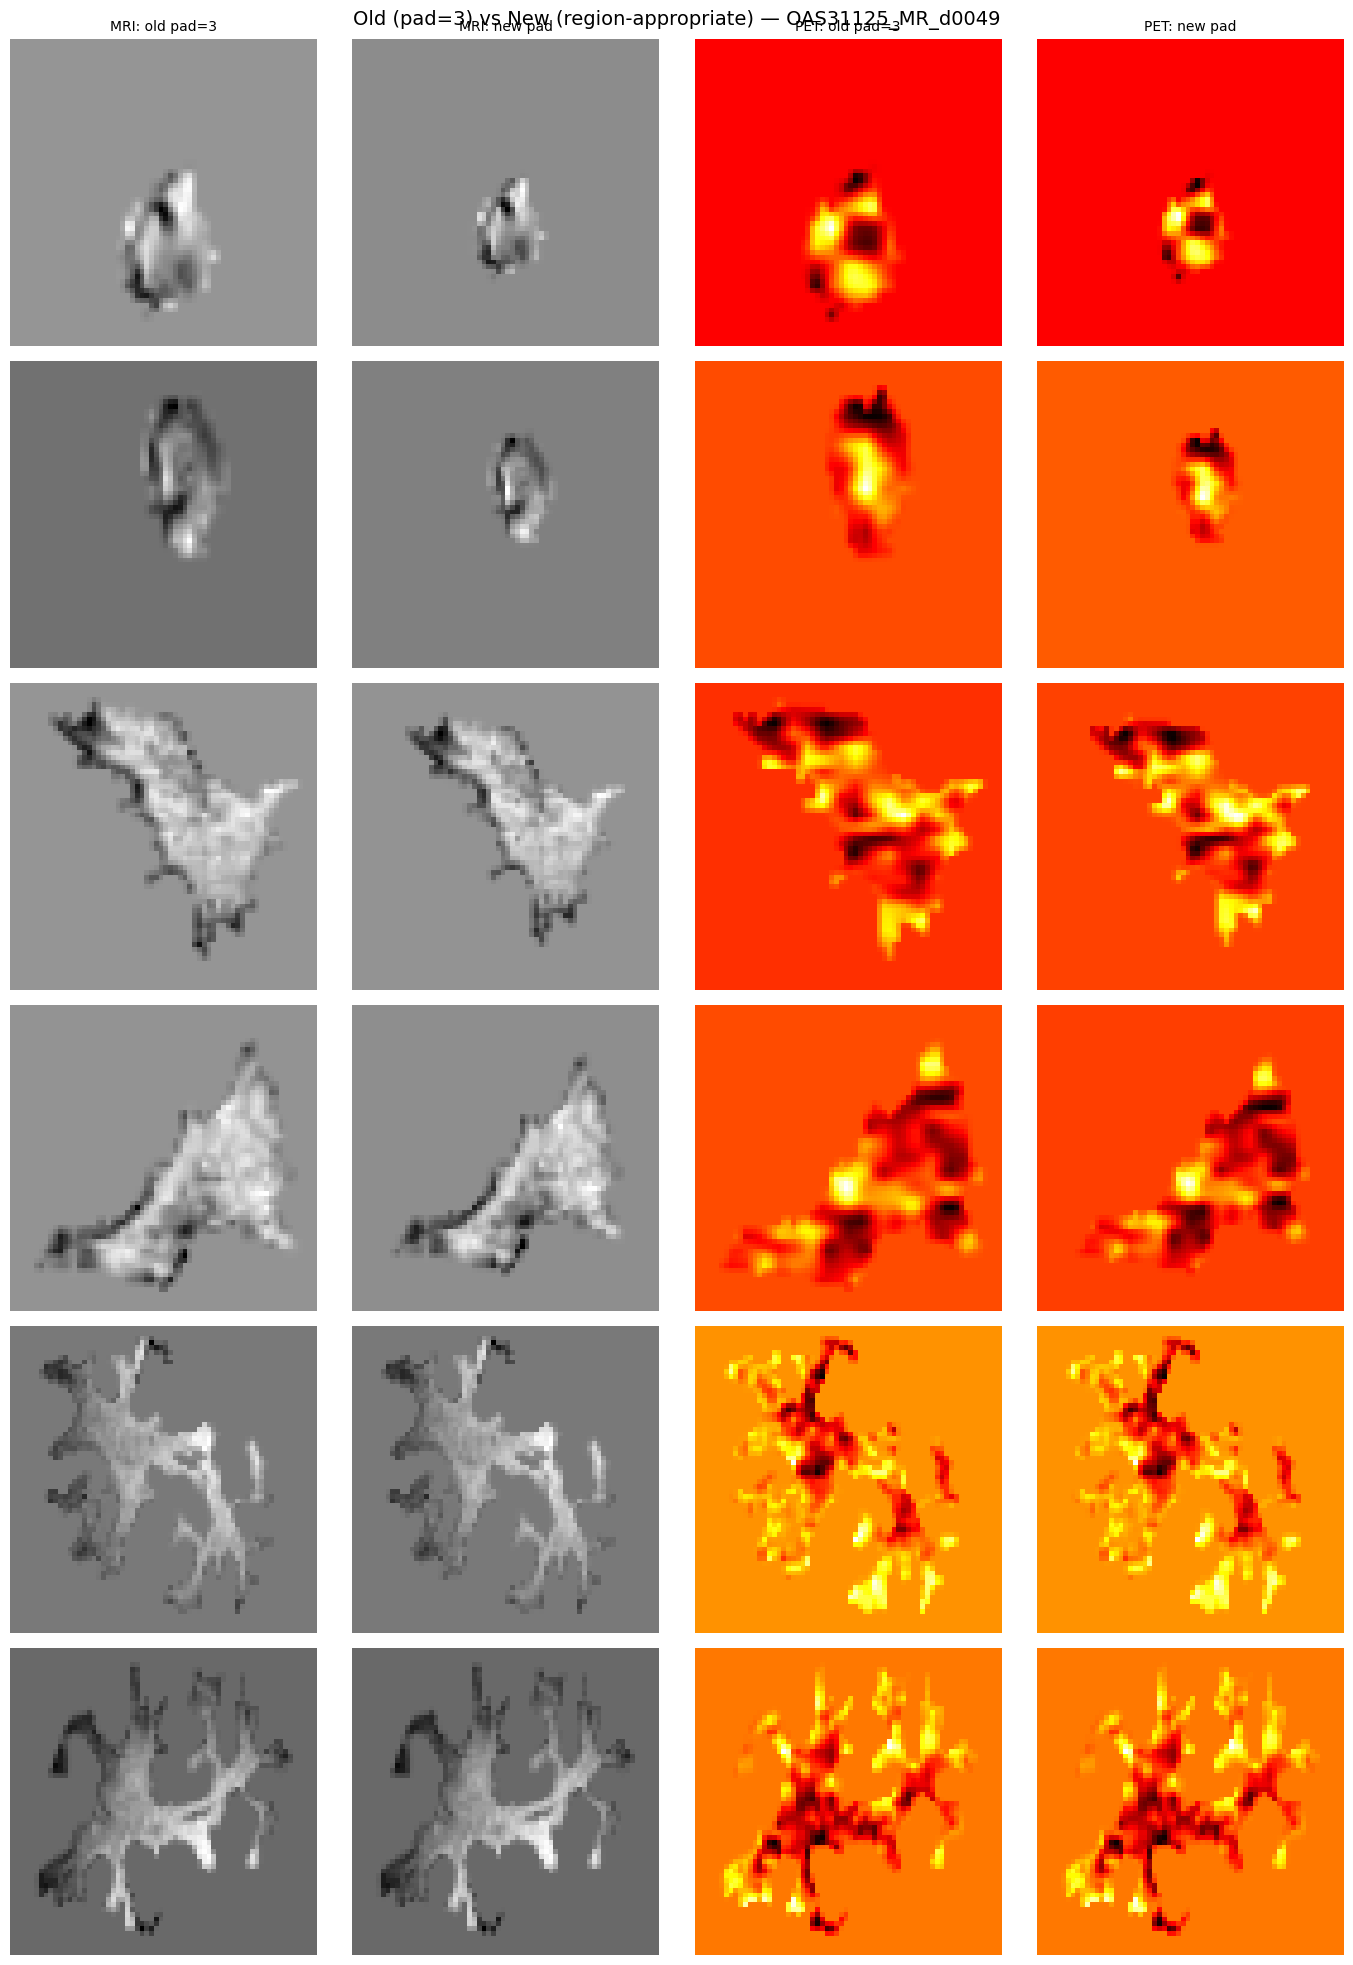

ROI                    |    Old MRI |    New MRI |    Old PET |    New PET
---------------------------------------------------------------------------
Left-Hippocampus       |      31230 |      11748 |      31230 |      11748
Right-Hippocampus      |      31173 |      11606 |      31173 |      11606
Left-Cerebellum-WM     |      32078 |      25133 |      32078 |      25133
Right-Cerebellum-WM    |      36499 |      26625 |      36499 |      26625
Left-Cerebral-WM       |      48499 |      48499 |      48499 |      48499
Right-Cerebral-WM      |      49281 |      49281 |      49281 |      49281


In [10]:
import matplotlib.pyplot as plt

OLD_MRI_CACHE = "D:/mamba_model/preprocessed_cache_roi64"
OLD_PET_CACHE = "D:/mamba_model/preprocessed_cache_pet"

ROI_NAMES = list(ROI_INFO_WITH_PADDING.keys())

session_id = X_val[0]
subject_id = session_to_subject[session_id]

old_mri = np.load(f"{OLD_MRI_CACHE}/{session_id}.npy")
new_mri = np.load(f"{MRI_CACHE}/{session_id}.npy")
old_pet = np.load(f"{OLD_PET_CACHE}/{subject_id}_PIB.npy")
new_pet = np.load(f"{PET_CACHE}/{subject_id}.npy")

fig, axes = plt.subplots(6, 4, figsize=(14, 20))
fig.suptitle(f"Old (pad=3) vs New (region-appropriate) — {session_id}", fontsize=14)

col_titles = ["MRI: old pad=3", "MRI: new pad", "PET: old pad=3", "PET: new pad"]
for c, title in enumerate(col_titles):
    axes[0, c].set_title(title, fontsize=10)

for i, roi_name in enumerate(ROI_NAMES):
    pad = ROI_INFO_WITH_PADDING[roi_name][1]
    mid = 32

    axes[i, 0].imshow(old_mri[i, :, :, mid], cmap='gray')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(new_mri[i, :, :, mid], cmap='gray')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(old_pet[i, :, :, mid], cmap='hot')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(new_pet[i, :, :, mid], cmap='hot')
    axes[i, 3].axis('off')

    axes[i, 0].set_ylabel(f"{roi_name}\n(pad={pad})", fontsize=9, rotation=0,
                           ha='right', va='center', labelpad=60)

plt.tight_layout()
plt.show()

# Nonzero voxel counts, to see the scale change per region
print(f"{'ROI':<22} | {'Old MRI':>10} | {'New MRI':>10} | {'Old PET':>10} | {'New PET':>10}")
print("-" * 75)
for i, roi_name in enumerate(ROI_NAMES):
    print(f"{roi_name:<22} | {(old_mri[i]!=0).sum():>10} | {(new_mri[i]!=0).sum():>10} | "
          f"{(old_pet[i]!=0).sum():>10} | {(new_pet[i]!=0).sum():>10}")